# DenseNet121 Production-ROI Robustness Fine-Tune

This is one controlled experiment for the observed border-focused heatmaps. It starts from the selected paired-view CE checkpoint, then fine-tunes **only YOLO-derived, labelled ROIs**.

Training crop: YOLO box, random expansion `1.10-1.20`, random centre shift up to `5%` of crop side, square crop, black padding only outside the radiograph. Validation crop: the fixed production rule, `1.15 x max(box width, box height)`, no shift.

Do not change the split, loss, input size, sampler, or preprocessing in this experiment. The checkpoint is selected by validation metrics; CAM measurements are reported separately and never used as a training loss.

In [1]:
!pip -q install "timm>=1.0" "ultralytics>=8.3,<9" "pandas>=2"

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import json
import math
import random
from datetime import datetime, timezone
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import average_precision_score, cohen_kappa_score, precision_recall_fscore_support, recall_score
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms
from tqdm.auto import tqdm
from ultralytics import YOLO

Mounted at /content/drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Fixed configuration

`BASE_CHECKPOINT` is the checkpoint currently mounted by the API. `YOLO_CHECKPOINT` must be the same detector used by the API. Update only paths if your Google Drive layout differs.

In [3]:
SEED = 42
INPUT_SIZE = 384
BATCH_SIZE = 48
NUM_WORKERS = 2
EPOCHS = 5
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-3
YOLO_CONFIDENCE = 0.45
YOLO_IMAGE_SIZE = 640
PRODUCTION_EXPANSION = 1.15
TRAIN_EXPANSION_RANGE = (1.10, 1.20)
TRAIN_SHIFT_FRACTION = 0.05
CAM_CASES_PER_GRADE = 50

DATASET_ROOT = Path('/content/drive/MyDrive/Datasets/KneeXrayData_Mendeley_v1')
PUBLISHED_ROOT = DATASET_ROOT / 'extracted/KneeXrayData/ClsKLData/kneeKL224'
FULL_PNG_ROOT = DATASET_ROOT / 'derived/full_bilateral_png_v2'
YOLO_CHECKPOINT = Path('/content/drive/MyDrive/Models/yolov8_checkpoint/best.pt')
BASE_CHECKPOINT = Path('/content/drive/MyDrive/Models/densenet121_paired_view_adaptation/2026-07-30_09-03-29_850983_UTC/best_model.pth')
RUN_TIMESTAMP = datetime.now(timezone.utc).strftime('%Y-%m-%d_%H-%M-%S_%f_UTC')
RUN_DIR = Path('/content/drive/MyDrive/Models/densenet121_production_roi_robustness') / RUN_TIMESTAMP
MANIFEST_PATH = DATASET_ROOT / 'derived/production_yolo_roi_manifest_v1.csv'

for required in (PUBLISHED_ROOT, FULL_PNG_ROOT, YOLO_CHECKPOINT, BASE_CHECKPOINT):
    if not required.exists():
        raise FileNotFoundError(f'Required path not found: {required}')
RUN_DIR.mkdir(parents=True, exist_ok=False)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('Run directory:', RUN_DIR)

Device: cuda
Run directory: /content/drive/MyDrive/Models/densenet121_production_roi_robustness/2026-07-30_15-45-03_830205_UTC


## Build or reuse the labelled production-ROI manifest

The manifest records the two YOLO boxes from each full bilateral radiograph and joins them to the existing published KL labels by patient ID and side. It does not copy images. Delete the CSV only when changing the YOLO checkpoint, detector confidence, or source dataset.

In [4]:
def published_labels():
    labels = {}
    for split in ('train', 'val'):
        for grade in range(5):
            for path in (PUBLISHED_ROOT / split / str(grade)).glob('*.png'):
                side = path.stem[-1].upper()
                patient = path.stem[:-1]
                if side not in ('R', 'L'):
                    raise RuntimeError(f'Cannot infer knee side from {path.name}')
                labels[(split, patient, side)] = grade
    return labels


labels = published_labels()
if MANIFEST_PATH.is_file():
    manifest = pd.read_csv(MANIFEST_PATH)
    required_columns = {'split', 'patient', 'side', 'grade', 'full_image', 'x1', 'y1', 'x2', 'y2'}
    if not required_columns.issubset(manifest.columns):
        raise RuntimeError(f'Old or invalid manifest: {MANIFEST_PATH}')
else:
    detector = YOLO(str(YOLO_CHECKPOINT))
    detector_device = 0 if torch.cuda.is_available() else 'cpu'
    rows = []
    for split in ('train', 'val'):
        paths = sorted((FULL_PNG_ROOT / split).glob('*.png'))
        for start in range(0, len(paths), BATCH_SIZE):
            batch_paths = paths[start:start + BATCH_SIZE]
            images = [cv2.imread(str(path), cv2.IMREAD_COLOR) for path in batch_paths]
            if any(image is None for image in images):
                raise RuntimeError(f'Cannot decode a full image in {split}')
            predictions = detector.predict(source=images, conf=YOLO_CONFIDENCE, imgsz=YOLO_IMAGE_SIZE, device=detector_device, batch=BATCH_SIZE, save=False, verbose=False)
            for path, prediction in zip(batch_paths, predictions):
                boxes = prediction.boxes.xyxy.detach().cpu().numpy()
                scores = prediction.boxes.conf.detach().cpu().numpy()
                boxes = boxes[np.argsort(scores)[::-1][:2]]
                boxes = sorted(boxes, key=lambda box: float(box[0] + box[2]))
                if len(boxes) != 2:
                    raise RuntimeError(f'Expected two YOLO knees for {path}; found {len(boxes)}')
                for box, side in zip(boxes, ('R', 'L')):
                    grade = labels.get((split, path.stem, side))
                    if grade is None:
                        raise RuntimeError(f'Missing KL label for {split}/{path.stem}{side}')
                    rows.append({'split': split, 'patient': path.stem, 'side': side, 'grade': grade, 'full_image': str(path), 'x1': float(box[0]), 'y1': float(box[1]), 'x2': float(box[2]), 'y2': float(box[3])})
            print(f'{split}: {min(start + len(batch_paths), len(paths))}/{len(paths)}')
    manifest = pd.DataFrame(rows)
    MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)
    manifest.to_csv(MANIFEST_PATH, index=False)

if manifest.duplicated(['split', 'patient', 'side']).any():
    raise RuntimeError('Manifest has duplicate patient-side rows')
print(manifest.groupby(['split', 'grade']).size().unstack(fill_value=0))
print('Manifest:', MANIFEST_PATH)

train: 48/2889
train: 96/2889
train: 144/2889
train: 192/2889
train: 240/2889
train: 288/2889
train: 336/2889
train: 384/2889
train: 432/2889
train: 480/2889
train: 528/2889
train: 576/2889
train: 624/2889
train: 672/2889
train: 720/2889
train: 768/2889
train: 816/2889
train: 864/2889
train: 912/2889
train: 960/2889
train: 1008/2889
train: 1056/2889
train: 1104/2889
train: 1152/2889
train: 1200/2889
train: 1248/2889
train: 1296/2889
train: 1344/2889
train: 1392/2889
train: 1440/2889
train: 1488/2889
train: 1536/2889
train: 1584/2889
train: 1632/2889
train: 1680/2889
train: 1728/2889
train: 1776/2889
train: 1824/2889
train: 1872/2889
train: 1920/2889
train: 1968/2889
train: 2016/2889
train: 2064/2889
train: 2112/2889
train: 2160/2889
train: 2208/2889
train: 2256/2889
train: 2304/2889
train: 2352/2889
train: 2400/2889
train: 2448/2889
train: 2496/2889
train: 2544/2889
train: 2592/2889
train: 2640/2889
train: 2688/2889
train: 2736/2889
train: 2784/2889
train: 2832/2889
train: 2880/2889
tr

## Exact ROI geometry, preprocessing, and DenseNet121

The crop function intentionally mirrors the API implementation. Training randomises only margin and centre; it never centre-crops away marginal osteophytes.

In [5]:
def make_square_roi(image, box, expansion, shift_fraction=0.0):
    height, width = image.shape[:2]
    x1, y1, x2, y2 = map(float, box)
    box_width, box_height = x2 - x1, y2 - y1
    if box_width <= 0 or box_height <= 0:
        raise ValueError(f'Invalid YOLO box: {box}')
    side = int(math.ceil(max(box_width, box_height) * expansion))
    center_x, center_y = (x1 + x2) / 2, (y1 + y2) / 2
    center_x += random.uniform(-shift_fraction, shift_fraction) * side
    center_y += random.uniform(-shift_fraction, shift_fraction) * side
    wanted_x1, wanted_y1 = int(math.floor(center_x - side / 2)), int(math.floor(center_y - side / 2))
    wanted_x2, wanted_y2 = wanted_x1 + side, wanted_y1 + side
    crop = image[max(0, wanted_y1):min(height, wanted_y2), max(0, wanted_x1):min(width, wanted_x2)]
    if crop.size == 0:
        raise RuntimeError(f'ROI has no overlap with the source image: {box}')
    return cv2.copyMakeBorder(crop, max(0, -wanted_y1), max(0, wanted_y2 - height), max(0, -wanted_x1), max(0, wanted_x2 - width), cv2.BORDER_CONSTANT, value=(0, 0, 0))


class OpenCVCLAHE:
    def __call__(self, image_rgb):
        lab = cv2.cvtColor(np.asarray(image_rgb), cv2.COLOR_RGB2LAB)
        lightness, a, b = cv2.split(lab)
        lightness = cv2.createCLAHE(clipLimit=1.25, tileGridSize=(8, 8)).apply(lightness)
        return cv2.cvtColor(cv2.merge((lightness, a, b)), cv2.COLOR_LAB2RGB)


class SquarePad:
    def __call__(self, image_rgb):
        image = np.asarray(image_rgb)
        height, width = image.shape[:2]
        side = max(height, width)
        top, left = (side - height) // 2, (side - width) // 2
        return cv2.copyMakeBorder(image, top, side - height - top, left, side - width - left, cv2.BORDER_CONSTANT, value=(0, 0, 0))


train_transform = transforms.Compose([
    OpenCVCLAHE(), SquarePad(), transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.50), transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)), transforms.ToTensor(),
    transforms.RandomErasing(p=0.10, scale=(0.02, 0.05), ratio=(0.5, 2.0), value=0),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    OpenCVCLAHE(), SquarePad(), transforms.ToPILImage(),
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)), transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


class ProductionROIDataset(Dataset):
    def __init__(self, frame, transform, training):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
        self.training = training
        self.labels = self.frame.grade.astype(int).tolist()

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        image = cv2.imread(row.full_image, cv2.IMREAD_COLOR)
        if image is None:
            raise RuntimeError(f'Cannot decode {row.full_image}')
        expansion = random.uniform(*TRAIN_EXPANSION_RANGE) if self.training else PRODUCTION_EXPANSION
        shift = TRAIN_SHIFT_FRACTION if self.training else 0.0
        roi = make_square_roi(image, [row.x1, row.y1, row.x2, row.y2], expansion, shift)
        rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
        return self.transform(rgb), int(row.grade), str(row.patient), str(row.side)


class DenseNet121Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model('densenet121', pretrained=False, num_classes=5, drop_rate=0.20)

    @property
    def gradcam_target_layer(self):
        return self.backbone.features.norm5

    def forward(self, images):
        return self.backbone(images)

## Baseline evaluation and controlled fine-tune

The baseline is evaluated on the same fixed production ROIs before training. The weighted sampler and CE loss match the preceding paired-view run. The best checkpoint is selected using QWK, macro F1, and macro AP on the fixed validation ROIs.

In [6]:
def load_model(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    if checkpoint.get('loss_type') not in (None, 'ce'):
        raise RuntimeError(f'Expected CE checkpoint; got {checkpoint.get("loss_type")}')
    model = DenseNet121Model().to(DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'], strict=True)
    return model, checkpoint


def evaluate(model, loader):
    labels, probabilities = [], []
    model.eval()
    with torch.inference_mode():
        for images, batch_labels, _, _ in loader:
            probs = F.softmax(model(images.to(DEVICE, non_blocking=True)).float(), dim=1).cpu().numpy()
            labels.extend(batch_labels.numpy())
            probabilities.extend(probs)
    labels, probabilities = np.asarray(labels), np.asarray(probabilities)
    predictions = probabilities.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, labels=list(range(5)), average='macro', zero_division=0)
    return {
        'accuracy': float(np.mean(labels == predictions)),
        'qwk': float(cohen_kappa_score(labels, predictions, weights='quadratic')),
        'macro_precision': float(precision), 'macro_recall': float(recall), 'macro_f1': float(f1),
        'grade4_recall': float(recall_score(labels == 4, predictions == 4, zero_division=0)),
        'macro_ap': float(average_precision_score(np.eye(5)[labels], probabilities, average='macro')),
    }


train_frame = manifest[manifest['split'] == 'train'].copy()
val_frame = manifest[manifest['split'] == 'val'].copy()
train_data = ProductionROIDataset(train_frame, train_transform, training=True)
val_data = ProductionROIDataset(val_frame, val_transform, training=False)
counts = np.bincount(train_frame.grade.to_numpy(), minlength=5)
weights = (1.0 / counts)[train_frame.grade.to_numpy()]
sampler = WeightedRandomSampler(torch.as_tensor(weights, dtype=torch.double), len(weights), replacement=True)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=NUM_WORKERS > 0)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=NUM_WORKERS > 0)

model, base_metadata = load_model(BASE_CHECKPOINT)
baseline_metrics = evaluate(model, val_loader)
print('Baseline fixed-production-ROI metrics:', json.dumps(baseline_metrics, indent=2))

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)
scaler = torch.amp.GradScaler('cuda', enabled=DEVICE.type == 'cuda')
best_score, history = -float('inf'), []

for epoch in range(1, EPOCHS + 1):
    model.train()
    loss_sum, samples = 0.0, 0
    for images, labels, _, _ in tqdm(train_loader, desc=f'fine-tune {epoch}/{EPOCHS}'):
        images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=DEVICE.type == 'cuda'):
            loss = F.cross_entropy(model(images), labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        loss_sum += loss.item() * labels.size(0)
        samples += labels.size(0)
    scheduler.step()
    metrics = evaluate(model, val_loader)
    score = 0.55 * metrics['qwk'] + 0.30 * metrics['macro_f1'] + 0.15 * metrics['macro_ap']
    row = {'epoch': epoch, 'train_loss': loss_sum / max(samples, 1), 'selection_score': score, **metrics}
    history.append(row)
    print(json.dumps(row, indent=2))
    if score > best_score:
        best_score = score
        torch.save({'model_state_dict': model.state_dict(), 'architecture': 'timm_densenet121_linear_gradcam', 'loss_type': 'ce', 'epoch': epoch, 'base_checkpoint': str(BASE_CHECKPOINT), 'yolo_checkpoint': str(YOLO_CHECKPOINT), 'roi_expansion_validation': PRODUCTION_EXPANSION, 'roi_expansion_training': TRAIN_EXPANSION_RANGE, 'roi_shift_fraction_training': TRAIN_SHIFT_FRACTION, 'validation_metrics': metrics, 'selection_score': score}, RUN_DIR / 'best_model.pth')

pd.DataFrame(history).to_csv(RUN_DIR / 'history.csv', index=False)
(RUN_DIR / 'run_config.json').write_text(json.dumps({'base_checkpoint': str(BASE_CHECKPOINT), 'yolo_checkpoint': str(YOLO_CHECKPOINT), 'loss': 'cross_entropy', 'input_size': INPUT_SIZE, 'batch_size': BATCH_SIZE, 'epochs': EPOCHS, 'sampler': 'inverse_frequency', 'production_roi': {'expansion': PRODUCTION_EXPANSION, 'shift_fraction': 0.0}, 'training_roi': {'expansion_range': TRAIN_EXPANSION_RANGE, 'shift_fraction': TRAIN_SHIFT_FRACTION}, 'preprocessing': 'CLAHE 1.25 -> SquarePad -> Resize 384'}, indent=2))
print('Selected checkpoint:', RUN_DIR / 'best_model.pth')

Baseline fixed-production-ROI metrics: {
  "accuracy": 0.5883777239709443,
  "qwk": 0.7405190839694656,
  "macro_precision": 0.6219044066226918,
  "macro_recall": 0.6323678548476199,
  "macro_f1": 0.621970669005519,
  "grade4_recall": 0.9259259259259259,
  "macro_ap": 0.6664602008060103
}


fine-tune 1/5:   0%|          | 0/121 [00:00<?, ?it/s]

{
  "epoch": 1,
  "train_loss": 0.832292905570562,
  "selection_score": 0.6894319668321637,
  "accuracy": 0.5835351089588378,
  "qwk": 0.7402469742581557,
  "macro_precision": 0.6046218487394958,
  "macro_recall": 0.6243854564886752,
  "macro_f1": 0.6103509955526359,
  "grade4_recall": 0.8148148148148148,
  "macro_ap": 0.6612722154959148
}


fine-tune 2/5:   0%|          | 0/121 [00:00<?, ?it/s]

{
  "epoch": 2,
  "train_loss": 0.790372994458564,
  "selection_score": 0.6946543896065626,
  "accuracy": 0.5980629539951574,
  "qwk": 0.7453165471959521,
  "macro_precision": 0.6241248313605702,
  "macro_recall": 0.6213213111598375,
  "macro_f1": 0.6192435492147246,
  "grade4_recall": 0.8888888888888888,
  "macro_ap": 0.6597148258958103
}


...

{
  "epoch": 3,
  "train_loss": 0.7702075719585795,
  "selection_score": 0.7120892772771086,
  "accuracy": 0.6198547215496368,
  "qwk": 0.7611406072898645,
  "macro_precision": 0.6356339206769979,
  "macro_recall": 0.6488174837353257,
  "macro_f1": 0.6396592582789853,
  "grade4_recall": 0.8888888888888888,
  "macro_ap": 0.6770944385599165
}


fine-tune 4/5:   0%|          | 0/121 [00:00<?, ?it/s]

{
  "epoch": 4,
  "train_loss": 0.7680609414386849,
  "selection_score": 0.7156137262254205,
  "accuracy": 0.6186440677966102,
  "qwk": 0.7649808754781131,
  "macro_precision": 0.6424937196945564,
  "macro_recall": 0.6523621751200863,
  "macro_f1": 0.6451166242407786,
  "grade4_recall": 0.8888888888888888,
  "macro_ap": 0.6755950496014979
}


fine-tune 5/5:   0%|          | 0/121 [00:00<?, ?it/s]

{
  "epoch": 5,
  "train_loss": 0.7584826230136281,
  "selection_score": 0.7108783646088126,
  "accuracy": 0.6162227602905569,
  "qwk": 0.7600729261622607,
  "macro_precision": 0.6375336081867349,
  "macro_recall": 0.6440990488336256,
  "macro_f1": 0.6391447017776946,
  "grade4_recall": 0.8518518518518519,
  "macro_ap": 0.6739656312417379
}
Selected checkpoint: /content/drive/MyDrive/Models/densenet121_production_roi_robustness/2026-07-30_15-45-03_830205_UTC/best_model.pth


## Grad-CAM audit: baseline versus candidate

This audits the same deterministic production ROIs for both checkpoints. `joint_energy` and `border_energy` are geometry heuristics for comparison, not clinical ground truth. Inspect the exported figures before accepting the candidate.

CAM baseline:   0%|          | 0/227 [00:00<?, ?it/s]

CAM candidate:   0%|          | 0/227 [00:00<?, ?it/s]

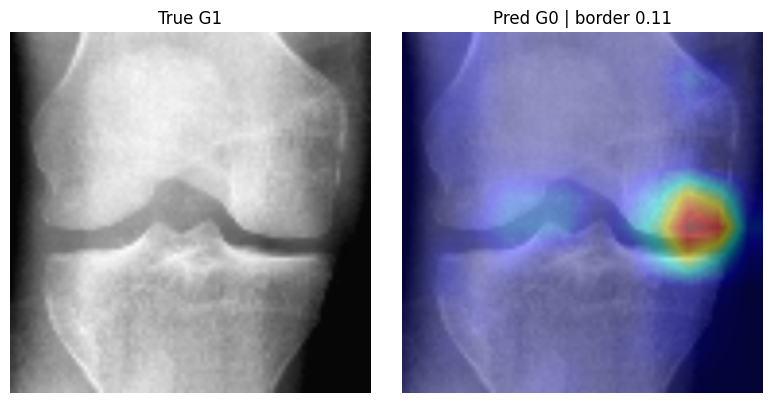

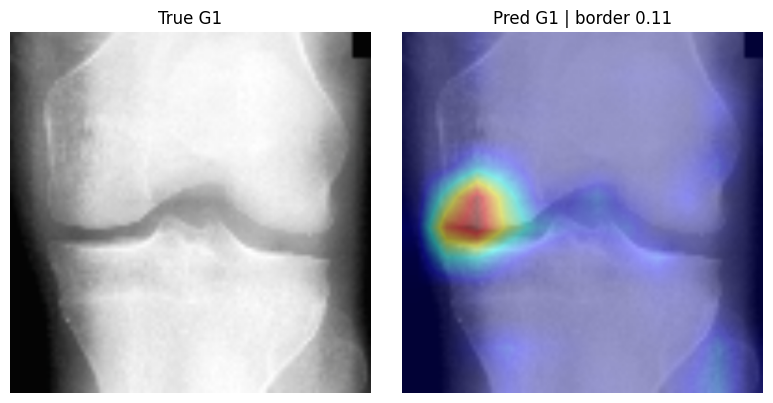

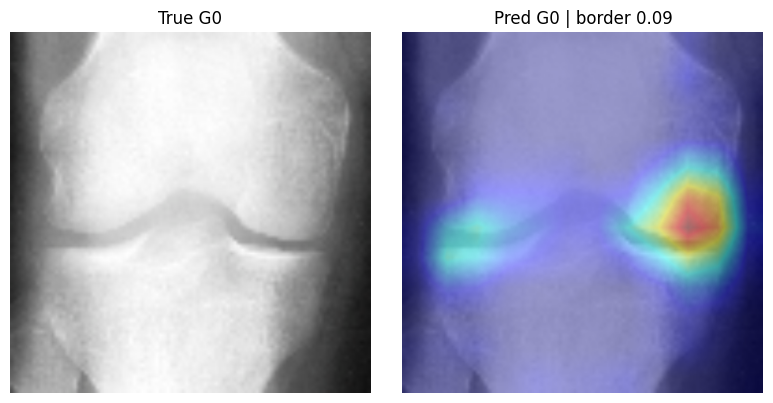

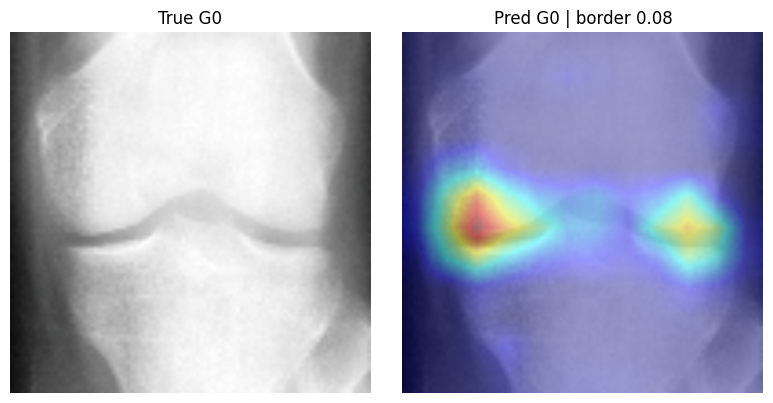

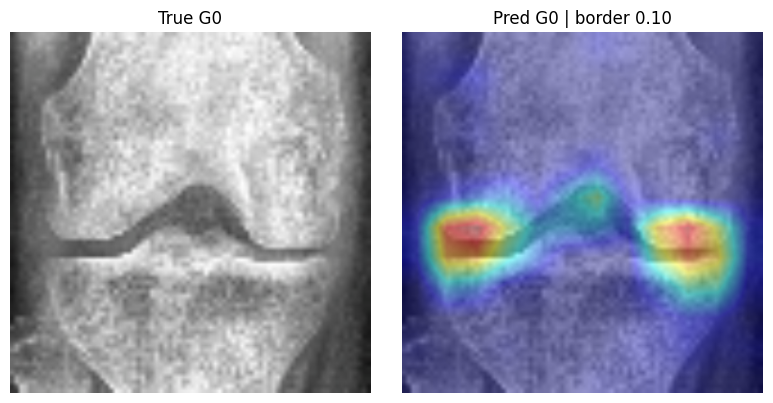

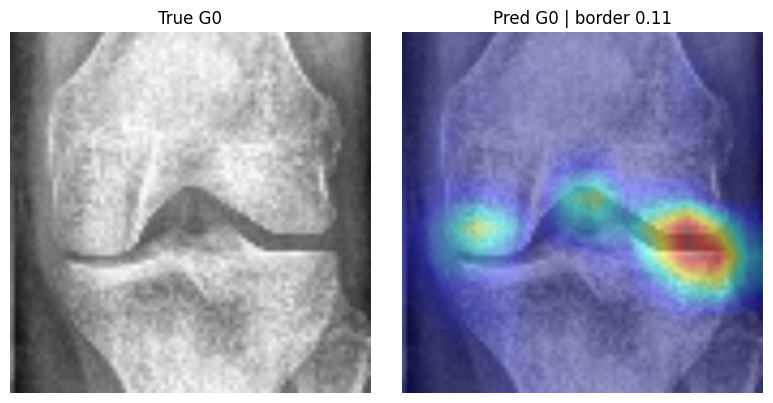

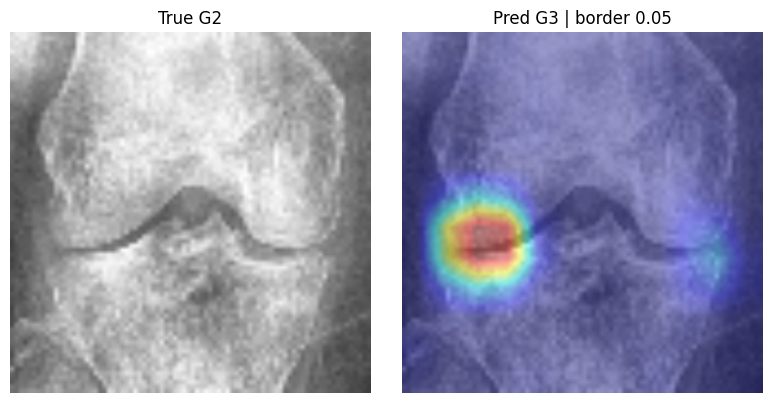

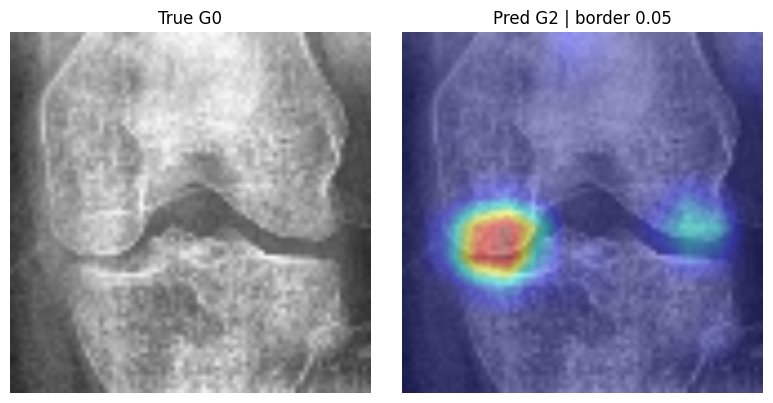

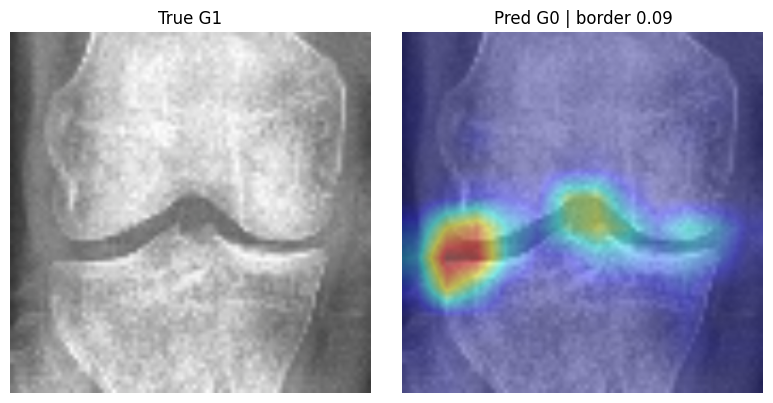

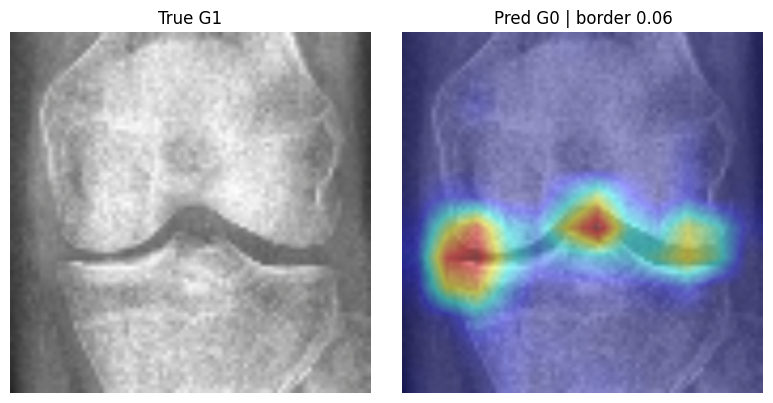

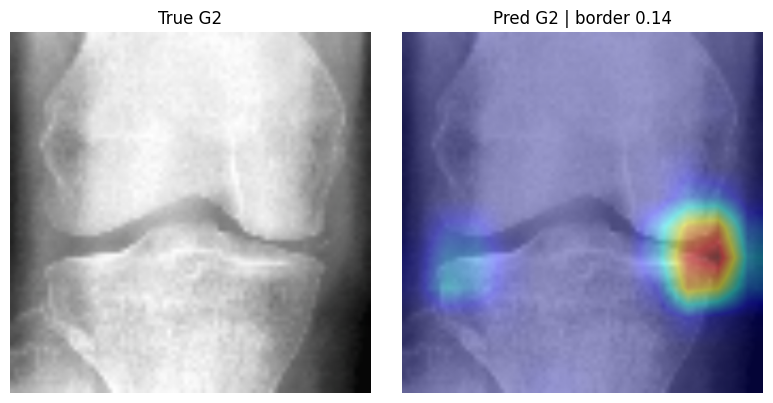

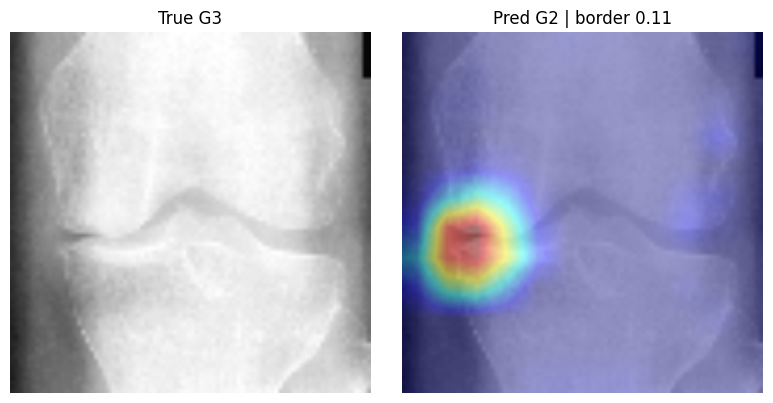

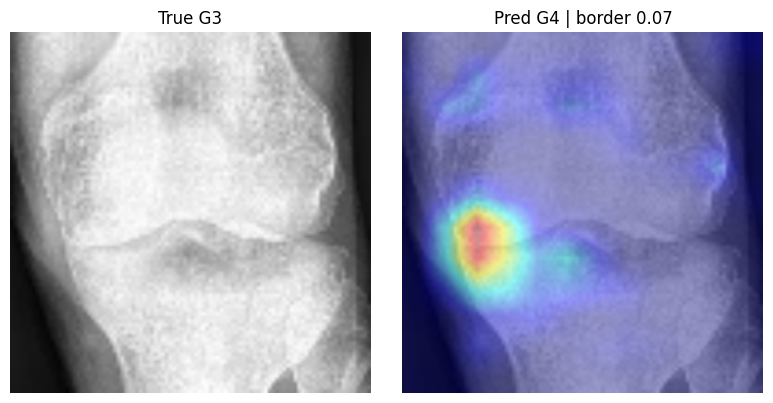

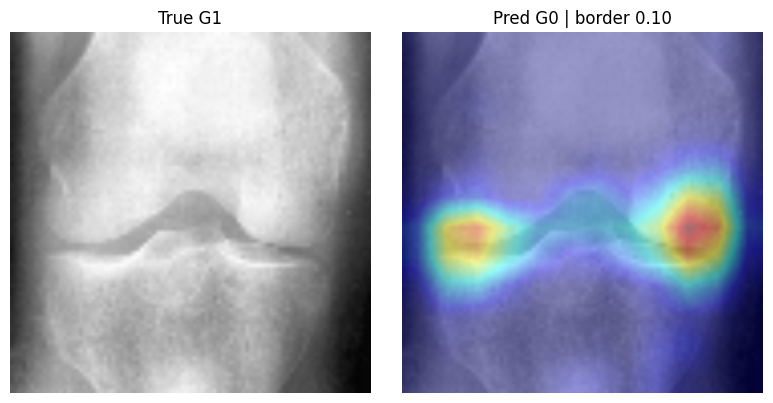

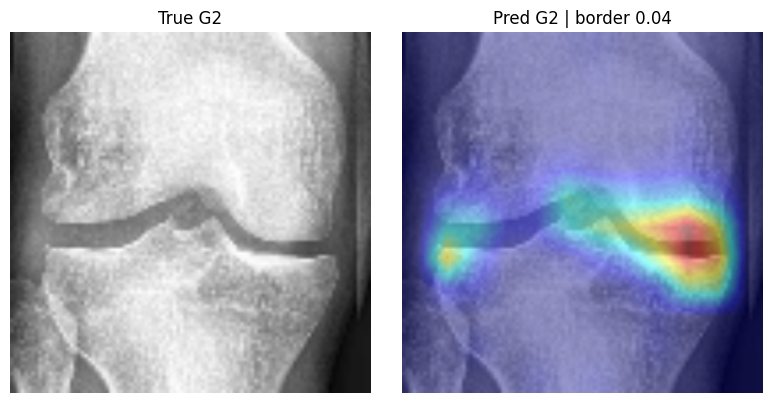

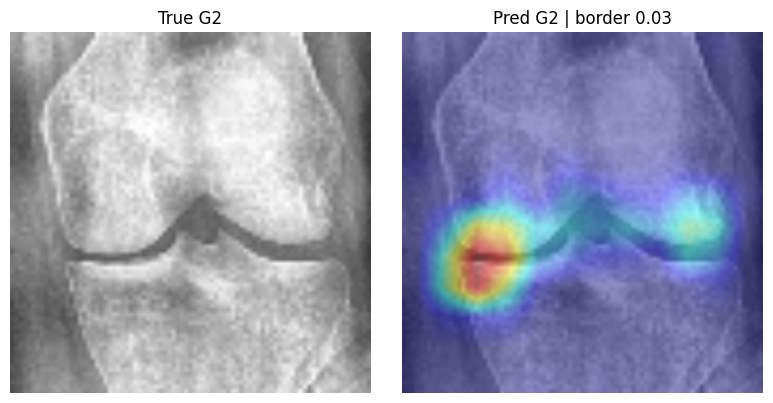

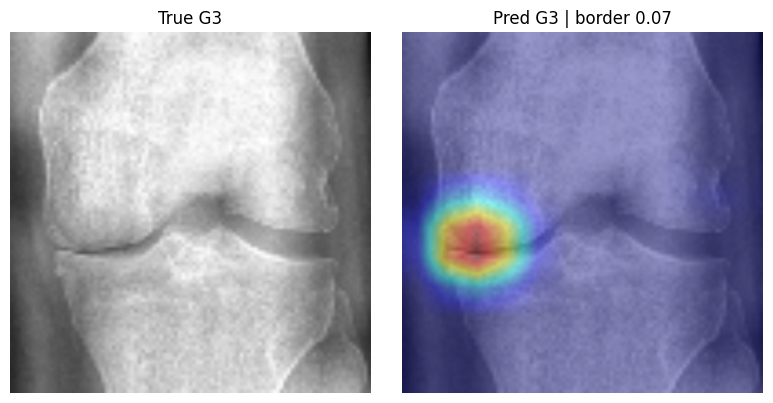

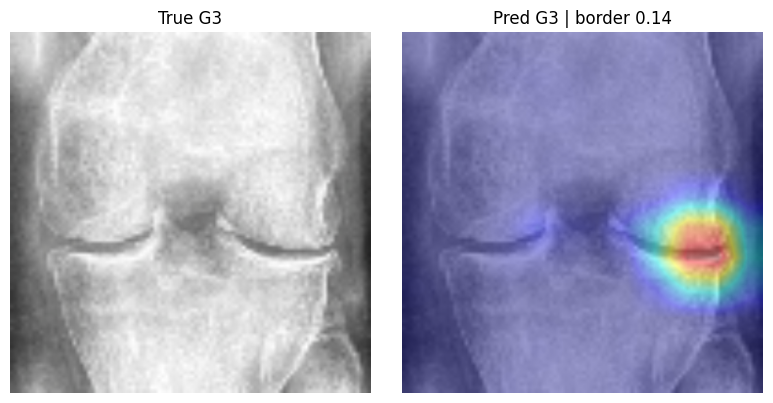

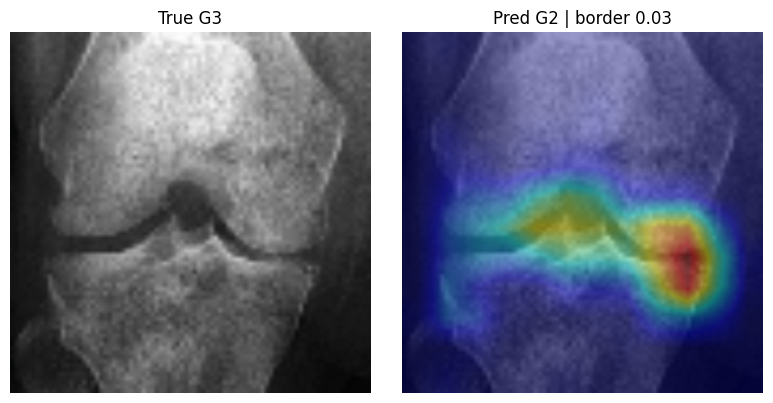

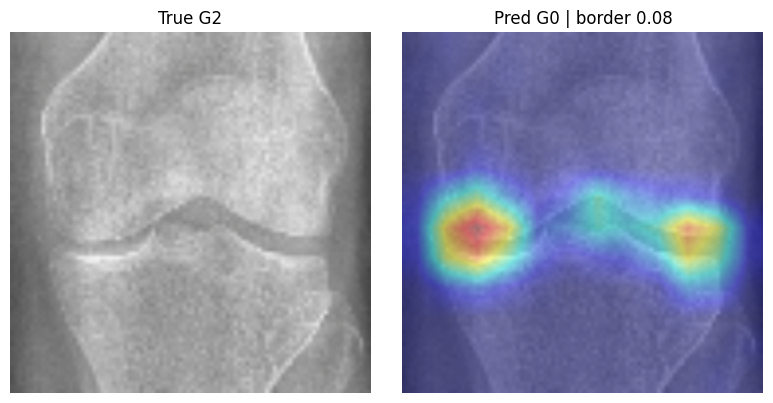

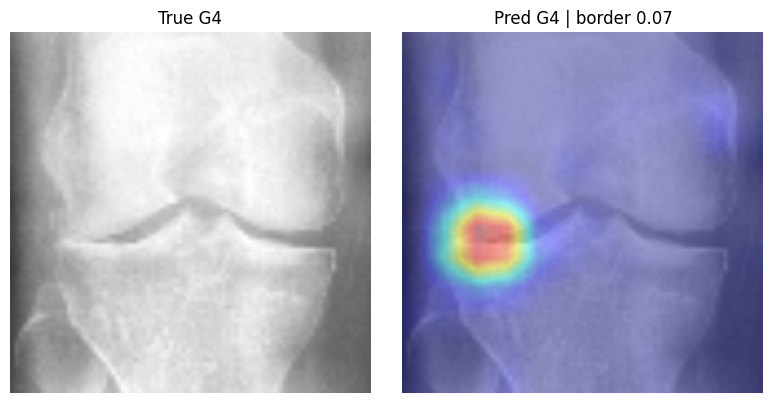

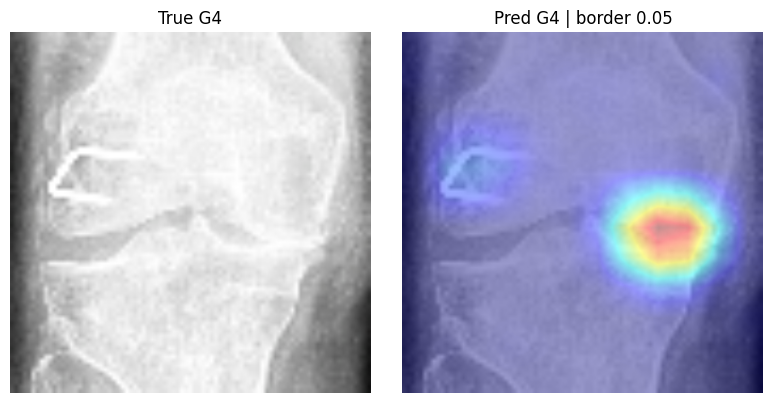

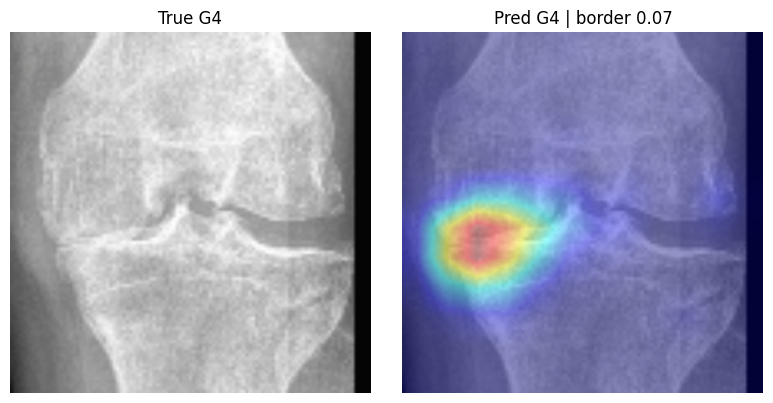

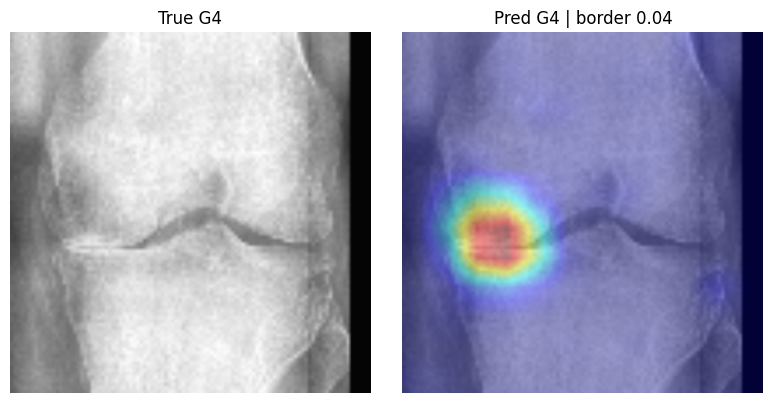

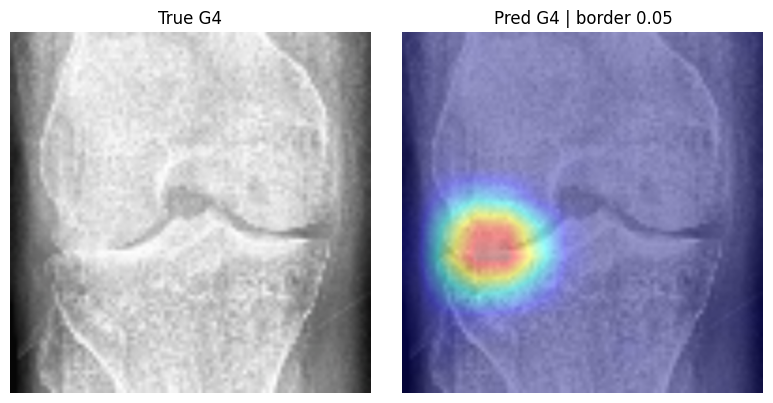

,checkpoint,joint_energy,border_energy,peak_inside_joint
0,baseline,0.864826,0.076058,0.995595
1,candidate,0.850468,0.084438,1.000000


Accept only when candidate metrics do not regress materially and candidate border energy decreases without a fall in joint energy.


In [7]:
class GradCAM:
    def __init__(self, model):
        self.model, self.activations, self.gradients = model, None, None
        self.handle = model.gradcam_target_layer.register_forward_hook(self._capture)

    def _capture(self, module, inputs, output):
        self.activations = output

    def remove(self):
        self.handle.remove()

    def __call__(self, tensor, target_class=None):
        self.model.eval(); self.model.zero_grad(set_to_none=True)
        self.activations = self.gradients = None
        with torch.enable_grad():
            logits = self.model(tensor.detach().clone().requires_grad_(True))
            prediction = int(logits.argmax(dim=1).item())
            target = prediction if target_class is None else int(target_class)
            self.activations.register_hook(lambda gradient: setattr(self, 'gradients', gradient))
            logits[0, target].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=tensor.shape[-2:], mode='bilinear', align_corners=False)[0, 0].detach().cpu().numpy()
        return prediction, F.softmax(logits.float(), dim=1)[0].detach().cpu().numpy(), cam / max(float(cam.max()), 1e-8)


def cam_measurements(cam):
    height, width = cam.shape
    border = np.ones_like(cam, dtype=bool); border[int(.08 * height):int(.92 * height), int(.08 * width):int(.92 * width)] = False
    joint = np.zeros_like(cam, dtype=bool); joint[int(.28 * height):int(.72 * height), int(.06 * width):int(.94 * width)] = True
    total = float(cam.sum()) + 1e-8
    peak = np.unravel_index(np.argmax(cam), cam.shape)
    return {'joint_energy': float(cam[joint].sum() / total), 'border_energy': float(cam[border].sum() / total), 'peak_inside_joint': bool(joint[peak])}


def overlay(image_rgb, cam):
    heatmap = cv2.cvtColor(cv2.applyColorMap(np.uint8(np.clip(cam, 0, 1) * 255), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(image_rgb, 0.60, heatmap, 0.40, 0)


audit_frame = val_frame.groupby('grade', group_keys=False).head(CAM_CASES_PER_GRADE).reset_index(drop=True)
audit_data = ProductionROIDataset(audit_frame, val_transform, training=False)

def audit_checkpoint(name, checkpoint_path, save_examples):
    audit_model, _ = load_model(checkpoint_path)
    cam_engine = GradCAM(audit_model)
    rows, examples = [], {grade: 0 for grade in range(5)}
    example_dir = RUN_DIR / 'gradcam_examples' / name
    example_dir.mkdir(parents=True, exist_ok=True)
    for index in tqdm(range(len(audit_data)), desc=f'CAM {name}'):
        tensor, grade, patient, side = audit_data[index]
        prediction, probabilities, cam = cam_engine(tensor.unsqueeze(0).to(DEVICE))
        measures = cam_measurements(cam)
        row = {'patient': patient, 'side': side, 'true_grade': grade, 'predicted_grade': prediction, 'confidence': float(probabilities[prediction]), **measures}
        rows.append(row)
        if save_examples and examples[grade] < 5:
            raw = cv2.imread(audit_frame.iloc[index].full_image, cv2.IMREAD_COLOR)
            box = audit_frame.iloc[index][['x1', 'y1', 'x2', 'y2']].tolist()
            roi = make_square_roi(raw, box, PRODUCTION_EXPANSION, 0.0)
            roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
            processed = np.asarray(transforms.Compose([OpenCVCLAHE(), SquarePad(), transforms.ToPILImage(), transforms.Resize((INPUT_SIZE, INPUT_SIZE))])(roi_rgb))
            plt.figure(figsize=(8, 4)); plt.subplot(1, 2, 1); plt.imshow(processed); plt.title(f'True G{grade}'); plt.axis('off'); plt.subplot(1, 2, 2); plt.imshow(overlay(processed, cam)); plt.title(f'Pred G{prediction} | border {measures["border_energy"]:.2f}'); plt.axis('off'); plt.tight_layout(); plt.savefig(example_dir / f'G{grade}_{patient}_{side}.png', dpi=150); plt.show(); plt.close()
            examples[grade] += 1
    cam_engine.remove()
    result = pd.DataFrame(rows)
    result.to_csv(RUN_DIR / f'{name}_gradcam_audit.csv', index=False)
    return result

baseline_cam = audit_checkpoint('baseline', BASE_CHECKPOINT, save_examples=False)
candidate_cam = audit_checkpoint('candidate', RUN_DIR / 'best_model.pth', save_examples=True)
cam_summary = pd.DataFrame([
    {'checkpoint': 'baseline', **baseline_cam[['joint_energy', 'border_energy', 'peak_inside_joint']].mean(numeric_only=True).to_dict()},
    {'checkpoint': 'candidate', **candidate_cam[['joint_energy', 'border_energy', 'peak_inside_joint']].mean(numeric_only=True).to_dict()},
])
cam_summary.to_csv(RUN_DIR / 'gradcam_summary.csv', index=False)
display(cam_summary)
print('Accept only when candidate metrics do not regress materially and candidate border energy decreases without a fall in joint energy.')

## Decision rule

Use the candidate only if its fixed-production-ROI QWK and macro F1 are not materially lower than baseline, Grade 4 recall/AP do not regress, and the Grad-CAM audit shows lower border energy without lower joint energy. Archive `history.csv`, `run_config.json`, both CAM CSV files, and the figures with the executed notebook before deployment.